[![Open In Colab](./colab-badge.png)](https://colab.research.google.com/github/subhacom/moose-notebooks/blob/main/Dynamical_system_with_NaP_and_K.ipynb) [![Binder](./binder_logo.png)](https://mybinder.org/v2/gh/subhacom/moose-notebooks/HEAD?labpath=Dynamical_system_with_NaP_and_K.ipynb)

# Dynamical system with NaP and K channels

In the last example we saw a system with only one fast Na channel. Since $m_{\infty}$ depended only on V and not time, the state of the neuron was completely defined by the single state variable V.

Now we will add a $K^+$ channel with open probablity $n$ so that the state of the neuron is described by two state variables $(V, n)$.

In [1]:
# Usual imports
import numpy as np
import matplotlib.pyplot as plt
import moose

INFO:numexpr.utils:NumExpr defaulting to 12 threads.


In [2]:
# Usual initialization
model_path = '/model'
data_path = '/data'

if moose.exists(model_path):
    moose.delete(model_path)
if moose.exists(data_path):
    moose.delete(data_path)

model = moose.Neutral(model_path)
data = moose.Neutral(data_path)

We will model this simplified system:

$C\frac{dV}{dt} = I - (V - E_{m})/R_{m} - \bar{G}_{Na} \times m_{\infty}(V)\times (V - E_{Na}) - \bar{G}_{K} \times n \times (V - E_{K})$

$\frac{dn}{dt} = \frac{n_{\infty}(V) - n}{\tau_{n}}$

Here the $Na^{+}$ channel dynamics is considered to be very fast, so that $m(V)$ reaches steady state value $m_{\infty}(V)$ instantaneously. However the $K^{+}$ channel is slow. We will keep $\tau_{n}$ constant to keep things simple. It would be 10 ms so that the K channel is slow.

In [3]:
# Create a single compartmental model with these two channels
comp = moose.Compartment(f'{model_path}/soma')
# NaP channel
na_chan = moose.HHChannel(f'{comp.path}/NaP')
moose.connect(comp, 'channel', na_chan, 'channel')

# K channel
k_chan = moose.HHChannel(f'{comp.path}/K')
moose.connect(comp, 'channel', k_chan, 'channel')

<moose.SingleMsg path=/Msgs[0]/singleMsg[1] id=5 dataIndex=1 fieldIndex=0>

In [4]:
# Recording tables for two state variables: Vm and n
vm_tab = moose.Table(f'{data.path}/Vm')
moose.connect(vm_tab, 'requestOut', comp, 'getVm')

# In moose HHCHannel the gates are called X, Y, and Z. 
# Here we only have n gate, which we set as the X gate 
n_tab = moose.Table(f'{data.path}/n')
moose.connect(n_tab, 'requestOut', k_chan, 'getX')


<moose.SingleMsg path=/Msgs[0]/singleMsg[3] id=5 dataIndex=3 fieldIndex=0>

We will use the same parameters as in the previous notebook:


$C_{m} = 10 \mu F$

$\bar{G}_{Na} = 74 mS$

$E_{Na} = 60 mV$

$g_{L} = 1/R_{m} = 19 mS$

$E_{L} = E_{m} = -67 mV$

$V_{1/2} = 1.5 mV$

$k = 16 mV$

In [5]:
na_chan.Xpower = 1
na_chan.instant = 1  # this makes X gate instantaneous
mgate = moose.element(na_chan.path + '/gateX')
mgate.infExpr = '1/(1 + exp((1.5e-3 - v)/16e-3))'
mgate.tauExpr = '1'
mgate.min = -120e-3   # Minimum voltage
mgate.max = 40e-3     # Maximum voltage
mgate.divs = 3000     # Granularity of the lookup table for minf

Now we will setup the K channel

In [6]:
k_chan.Xpower = 1
ngate = moose.element(k_chan.path + '/gateX')
# We set a low threshold for the K channel with a sigmoid whose vhalf = -50 mV
ngate.infExpr = '1/(1 + exp((-50e-3 - v)/10e-3))'   
# Time constants are often similar to a bell curve
# and modeled as tau(V) = C_base + C_amp * exp(-(Vmax - V)^2 / sigma^2)
# ngate.tauExpr = '2e-3 + 0.01 * exp(-((-50e-3 - v)/25e-3)^2)'    # Note the ^ symbol for power instead of ** as in Python
ngate.tauExpr = '10e-3'
ngate.min = -120e-3
ngate.max = 40e-3
ngate.divs = 3000

We can plot the curves directly by evaluating these equations in Python

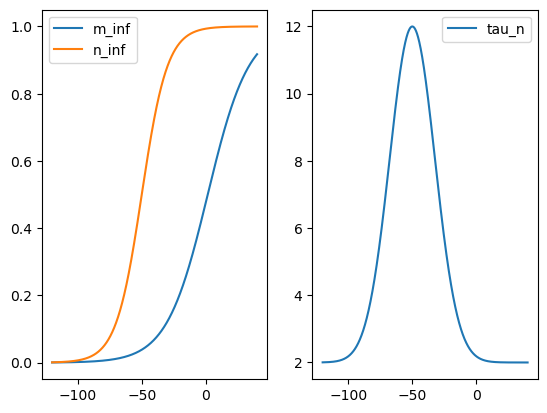

In [7]:
v = np.linspace(-120e-3, 40e-3, 3001)
minf = 1/(1 + np.exp((1.5e-3 - v)/16e-3))
taum = 1.0
ninf = 1/(1 + np.exp((-50e-3 - v)/10e-3))
taun = 2e-3 + 0.01 * np.exp(-((-50e-3 - v)/25e-3)**2)
fig, ax = plt.subplots(ncols=2)
ax[0].plot(v*1e3, minf, label='m_inf')
ax[0].plot(v*1e3, ninf, label='n_inf')
ax[1].plot(v*1e3, taun*1e3, label='tau_n')
for a in ax: 
    a.legend()

Now we set the parameters for the compartment and the channels

In [8]:
comp.Cm = 10e-6
comp.Rm = 1/19e-3
comp.Em = -67e-3
na_chan.Gbar = 74e-3
na_chan.Ek = 60e-3
k_chan.Gbar = 370e-3
k_chan.Ek = -80e-3

Finally we conduct the same experiment as before

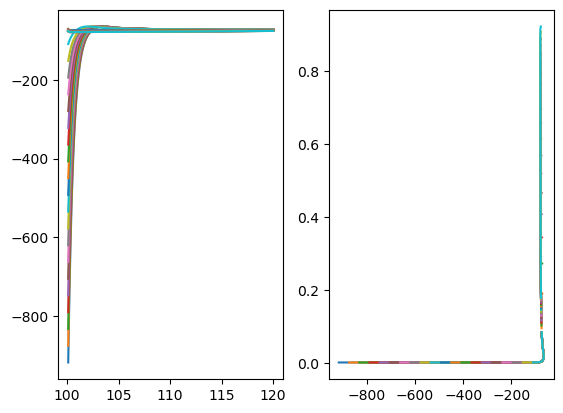

In [9]:
pre_time = 100e-3
post_time = 20e-3

comp.initVm = comp.Em

post_inject = 0.0

plot_tstart = pre_time

fig, axes = plt.subplots(ncols=2)
for pre_inject in np.arange(-20e-3, 20e-3, 1e-3):
    moose.reinit()
    comp.inject = pre_inject
    moose.start(pre_time)
    comp.inject = post_inject
    moose.start(post_time)
    t = np.linspace(0, pre_time + post_time, len(vm_tab.vector))
    axes[0].plot(t[t > plot_tstart]*1e3, vm_tab.vector[t > plot_tstart]*1e3)
    axes[1].plot(vm_tab.vector[t > plot_tstart] * 1e3, n_tab.vector[t > plot_tstart])

In [15]:
pre_time = 100e-3
post_time = 200e-3

comp.initVm = comp.Em

post_inject = 0.0

plot_tstart = pre_time
n_series = []
v_series = []
injection = []


for pre_inject in np.arange(-2e-3, 2e-3, 0.5e-3):
    for post_inject in np.arange(0.0, 5e-3, 1e-3):
        moose.reinit()
        comp.inject = pre_inject
        moose.start(pre_time)
        comp.inject = post_inject
        moose.start(post_time)
        n_series.append(n_tab.vector)
        v_series.append(vm_tab.vector)
        injection.append((pre_inject, post_inject))

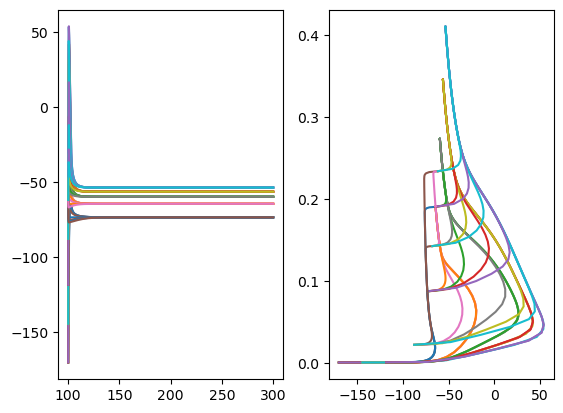

In [16]:
fig, axes = plt.subplots(ncols=2)
for vm, n in zip(v_series, n_series):
        t = np.linspace(0, pre_time + post_time, len(v))
        axes[0].plot(t[t > plot_tstart]*1e3, vm[t > plot_tstart]*1e3)
        axes[1].plot(vm[t > plot_tstart] * 1e3, n[t > plot_tstart])

We can use quiver plot to display the trajectories

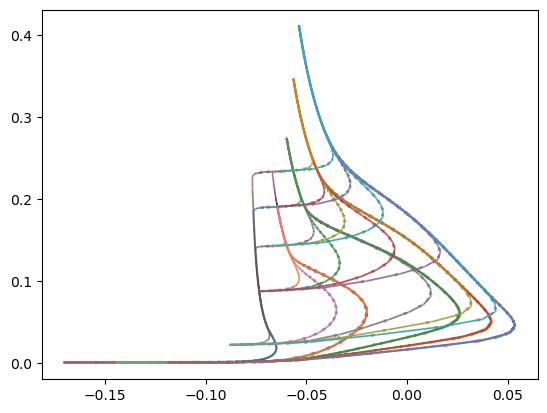

In [18]:
for vm, n in zip(v_series, n_series):
    t = np.linspace(0, pre_time + post_time, len(vm))
    v_post = vm[t > plot_tstart]
    n_post = n[t > plot_tstart]
    colors = np.arange(len(v_post)-1)
    plt.plot(v_post, n_post, alpha=0.5)
    plt.quiver(v_post[:-1], n_post[:-1], np.diff(v_post), np.diff(n_post), angles='xy', scale_units='xy', scale=1, alpha=0.5)

The current injection may not always take us to all possible initial states $(V, n)$. We could directly set these values by setting `comp.initVm` before `moose.reinit` and `k_chan.X` after reinit (because at reinit moose will look up the steady state value for `X` at `initVm`.

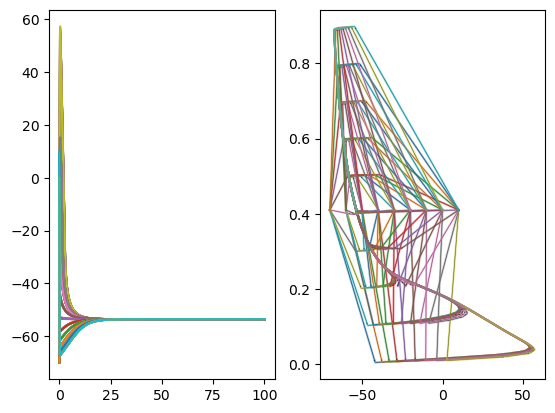

In [22]:
simtime = 100e-3

n_series = []
v_series = []

for n in np.arange(0, 1, 0.1):
    for vm in np.arange(-70e-3, 20e-3, 10e-3):
        comp.initVm = vm
        moose.reinit()
        k_chan.X = n
        moose.start(simtime)
        n_series.append(n_tab.vector)
        v_series.append(vm_tab.vector)
        
fig, axes = plt.subplots(ncols=2)
for vm, n in zip(v_series, n_series):
    t = np.linspace(0, simtime, len(vm)) * 1e3
    v = vm * 1e3    
    axes[0].plot(t, v)
    axes[1].plot(v, n, alpha=0.5)        
    axes[1].quiver(v[:-1], n[:-1], np.diff(v), np.diff(n), angles='xy', scale_units='xy', scale=1.0)  #, alpha=0.5)